# FIR (fixed point)

This notebook presents basic FIR implementation using fixed point format. First, let us install all dependencies

In [1]:
!pip install numpy scipy matplotlib fxpmath

Import them

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from fxpmath import Fxp
from scipy.signal import firwin, lfilter

Now, let us generate a multitone waveform and plot it

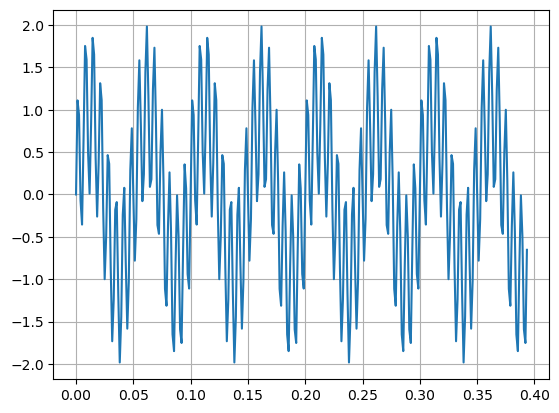

In [3]:
A = np.array([[2, 3, 5]])
f = np.array([[10, 50, 76]])
fs = np.max(f) * 10
t = np.arange(0, 2 * np.pi, 1 / fs)
x = 2 * np.pi * np.transpose(f).dot(np.array([t]))
x = np.transpose(A) * x
y = np.sin(x)
y = np.sum(y, axis = 0)

plt.figure()
plt.plot(t[:300], y[:300])
plt.grid()

Now, let's convert the waveform to fixed point format and plot it again

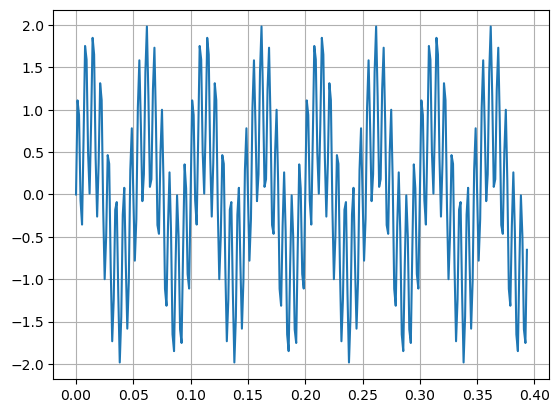

In [4]:
n_word = 18
n_frac = n_word - 2
signed = True
y_fxp = Fxp(y, signed = signed, n_word = n_word, n_frac = n_frac)

plt.figure()
plt.plot(t[:300], y_fxp[:300])
plt.grid()

Calculate the delta between the two formats and plot it as well

Max delta 0.0000152588


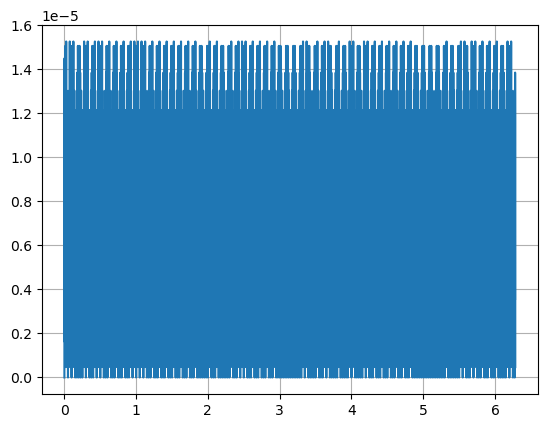

In [5]:
delta = np.abs(y - y_fxp)
print(f"Max delta {float(np.max(delta)):.10f}")

plt.figure()
plt.plot(t, delta)
plt.grid()

Calculate FIR coefficients and convert them to fixed point representation

In [6]:
fcutoff = 1.5 * np.min(f)
numtaps = 43
coeffs = firwin(numtaps, fcutoff, fs = fs)
coeffs_fxp = Fxp(coeffs, signed = signed, n_word = n_word, n_frac = n_frac)

Apply the filter to both floating point and fixed point representations and compare the results

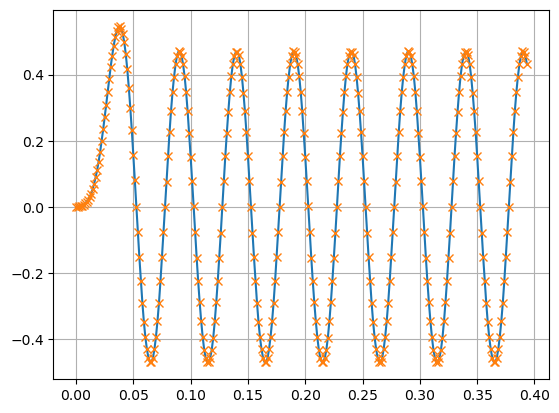

In [7]:
y_filtered = lfilter(coeffs, 1, y)
y_filtered_fxp = lfilter(coeffs, 1, y_fxp)

plt.figure()
plt.plot(t[:300], y_filtered[:300])
plt.plot(t[:300], y_filtered_fxp[:300], 'x')
plt.grid()

Max delta 0.0000042881


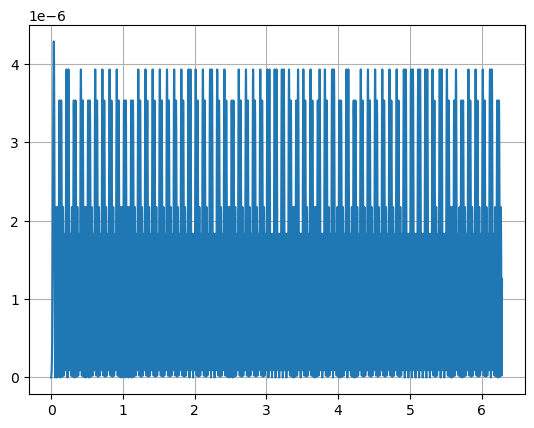

In [12]:
delta = np.abs(y_filtered - y_filtered_fxp)
print(f"Max delta {float(np.max(delta)):.10f}")

plt.figure()
plt.plot(t, delta)
plt.grid()